In [1]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.manifold import Isomap
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import joblib
import utils
from utils import plot_y_yhat,clean_train_data,error_metric, predict_average,baseline_cross_validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool

In [2]:
train=pd.read_csv('data/train_data.csv')
test=pd.read_csv('data/test_data.csv')
sample_submission=pd.read_csv('data/sample_submission.csv')

Cross-validation error: 2.7039
Test error: 2.4366
Training error: 2.4152


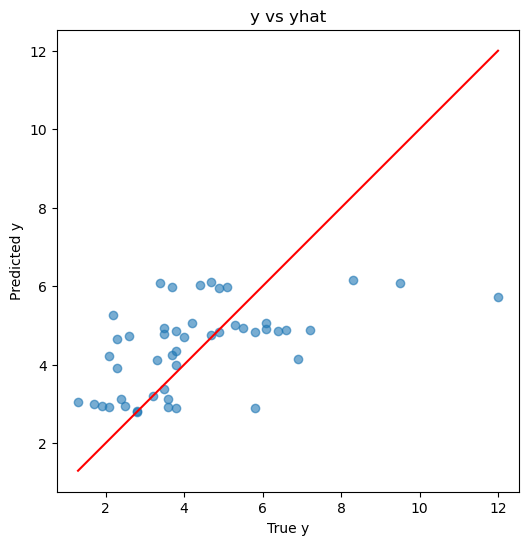

In [3]:
# TASK 4.1 - STEP 1: IMPUTATION WITH LABELED AND UNLABELED DATA

# Labeled data: SurvivalTime not null
labeled_data = train[train['SurvivalTime'].notna()].copy()
# Unlabeled data: SurvivalTime null  
unlabeled_data = train[train['SurvivalTime'].isna()].copy()

feature_cols = [col for col in train.columns 
               if col not in ['SurvivalTime', 'Censored', 'id']]

X_labeled = labeled_data[feature_cols]
y_labeled = labeled_data['SurvivalTime']
c_labeled = labeled_data['Censored']

X_unlabeled = unlabeled_data[feature_cols]
X_test_kaggle = test[feature_cols]

#  SPLIT LABELED DATA INTO TRAIN/TEST
X_train_labeled, X_test_labeled, y_train_labeled, y_test_labeled, c_train_labeled, c_test_labeled = train_test_split(
    X_labeled, y_labeled, c_labeled, test_size=0.2, random_state=42, stratify=c_labeled
)
#  APPLY KNN IMPUTATION ON ALL TRAINING DATA (labeled_train + unlabeled)
X_train_all = pd.concat([X_train_labeled, X_unlabeled], axis=0)

knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")
X_train_imputed = knn_imputer.fit_transform(X_train_all)

# Transform test data using the fitted imputer
X_test_labeled_imputed = knn_imputer.transform(X_test_labeled)
X_test_kaggle_imputed = knn_imputer.transform(X_test_kaggle)

# Split back into labeled train and unlabeled
n_labeled_train = len(X_train_labeled)
X_train_labeled_imputed = X_train_imputed[:n_labeled_train]
X_unlabeled_imputed = X_train_imputed[n_labeled_train:]

#  STANDARDIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_train_labeled_scaled = X_train_scaled[:n_labeled_train]
X_test_labeled_scaled = scaler.transform(X_test_labeled_imputed)
X_test_kaggle_scaled = scaler.transform(X_test_kaggle_imputed)

#  CROSS-VALIDATION ON TRAINING DATA
linear_model = LinearRegression()

# Cross-validation predictions
y_pred_cv = cross_val_predict(linear_model, X_train_labeled_scaled, y_train_labeled, cv=5)
cv_error = error_metric(y_train_labeled, y_pred_cv, c_train_labeled)

print(f"Cross-validation error: {cv_error:.4f}")

#  TRAIN FINAL MODEL ON FULL TRAINING DATA
linear_model.fit(X_train_labeled_scaled, y_train_labeled)

# 6. EVALUATE ON TEST DATA
y_pred_test = linear_model.predict(X_test_labeled_scaled)
test_error = error_metric(y_test_labeled, y_pred_test, c_test_labeled)

print(f"Test error: {test_error:.4f}")

# COMPARE TRAINING ERROR
y_pred_train = linear_model.predict(X_train_labeled_scaled)
train_error = error_metric(y_train_labeled, y_pred_train, c_train_labeled)
print(f"Training error: {train_error:.4f}")
plot_y_yhat(y_test_labeled, y_pred_test)



# 9. FINAL MODEL FOR KAGGLE (train on all labeled data)
X_all_labeled_imputed = knn_imputer.transform(X_labeled)
X_all_labeled_scaled = scaler.transform(X_all_labeled_imputed)

linear_model_final = LinearRegression()
linear_model_final.fit(X_all_labeled_scaled, y_labeled)

# 10. KAGGLE PREDICTIONS
y_pred_kaggle = linear_model_final.predict(X_test_kaggle_scaled)

submission = pd.DataFrame({
    'id': test.index, 
    0: y_pred_kaggle
})
submission.to_csv('semisupervised-submission-3.csv', index=False)



In [4]:

class FrozenTransformer(BaseEstimator):
    def __init__(self, fitted_transformer):
        self.fitted_transformer = fitted_transformer

    def __getattr__(self, name):
        return getattr(self.fitted_transformer, name)

    def __sklearn_clone__(self):
        return self

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return self.fitted_transformer.transform(X)

    def fit_transform(self, X, y=None):
        return self.fitted_transformer.transform(X)


In [5]:
#  TRAIN ISOMAP ON ALL DATA (labeled + unlabeled)
# Try different numbers of components
X_train_all = pd.concat([X_labeled, X_unlabeled], axis=0)

knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")
X_train_imputed = knn_imputer.fit_transform(X_train_all)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Split back to get scaled labeled data
n_labeled = len(X_labeled)
X_labeled_scaled = X_train_scaled[:n_labeled] 
n_components_options = [2, 5, 10, 15, 20]
best_isomap = None
best_n_components = None
best_train_error = float('inf')

for n_components in n_components_options:
    print(f"   Testing n_components={n_components}...")
    
    try:
        # Train Isomap on ALL data (semi-supervised)
        isomap = Isomap(n_components=n_components, n_jobs=-1)
        isomap.fit(X_train_scaled)  # Uses both labeled and unlabeled
        
        # Create frozen transformer
        frozen_isomap = FrozenTransformer(isomap)
        
        # Transform the labeled data for training
        X_labeled_transformed = frozen_isomap.transform(X_labeled_scaled)
        
        # Train linear regression on transformed labeled data
        lr_isomap = LinearRegression()
        lr_isomap.fit(X_labeled_transformed, y_labeled)
        
        # Evaluate on training data
        y_pred_train = lr_isomap.predict(X_labeled_transformed)
        train_error = error_metric(y_labeled, y_pred_train, c_labeled)
        
        print(f"     Training error: {train_error:.4f}")
        
        if train_error < best_train_error:
            best_train_error = train_error
            best_n_components = n_components
            best_isomap = isomap
            best_frozen_isomap = frozen_isomap
            best_lr = lr_isomap
            
    except Exception as e:
        print(f"     Error: {e}")

print(f"\n    Best Isomap: n_components={best_n_components}, error={best_train_error:.4f}")


   Testing n_components=2...
     Training error: 2.8753
   Testing n_components=5...
     Training error: 2.5947
   Testing n_components=10...
     Training error: 2.5375
   Testing n_components=15...
     Training error: 2.4338
   Testing n_components=20...
     Training error: 2.3472

    Best Isomap: n_components=20, error=2.3472


Labeled train: 192, Labeled test: 48
Unlabeled: 160
Cross-validation error: 3.0799
Test error: 2.6135
Training error: 2.4397


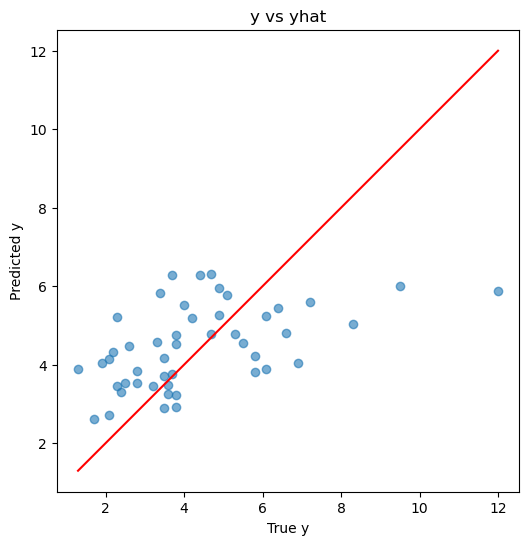

In [6]:
# FINAL PIPELINE WITH ISOMAP n_components=20 
# 1. SPLIT LABELED DATA INTO TRAIN/TEST
X_train_labeled, X_test_labeled, y_train_labeled, y_test_labeled, c_train_labeled, c_test_labeled = train_test_split(
    X_labeled, y_labeled, c_labeled, test_size=0.2, random_state=42, stratify=c_labeled
)

print(f"Labeled train: {len(X_train_labeled)}, Labeled test: {len(X_test_labeled)}")
print(f"Unlabeled: {len(X_unlabeled)}")

# 2. PRE-TRAIN ISOMAP ON ALL DATA (labeled_train + unlabeled)
X_train_all = pd.concat([X_train_labeled, X_unlabeled], axis=0)

knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")
X_train_imputed = knn_imputer.fit_transform(X_train_all)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

iso = Isomap(n_components=20, n_jobs=-1)
iso.fit(X_train_scaled)

# 3. CREATE THE FROZEN PIPELINE
pipe = make_pipeline(
    KNNImputer(n_neighbors=5),      # Imputation
    StandardScaler(),               # Standardization  
    FrozenTransformer(iso),         # Frozen Isomap (pre-trained)
    LinearRegression()              # Regression
)

# 4. CROSS-VALIDATION ON TRAINING DATA
y_pred_cv = cross_val_predict(pipe, X_train_labeled, y_train_labeled, cv=5)
cv_error = error_metric(y_train_labeled, y_pred_cv, c_train_labeled)

print(f"Cross-validation error: {cv_error:.4f}")

# 5. TRAIN FINAL PIPELINE ON TRAINING DATA
pipe.fit(X_train_labeled, y_train_labeled)

# 6. EVALUATE ON TEST DATA
y_pred_test = pipe.predict(X_test_labeled)
test_error = error_metric(y_test_labeled, y_pred_test, c_test_labeled)

print(f"Test error: {test_error:.4f}")

# 7. COMPARE TRAINING ERROR
y_pred_train = pipe.predict(X_train_labeled)
train_error = error_metric(y_train_labeled, y_pred_train, c_train_labeled)
print(f"Training error: {train_error:.4f}")
plot_y_yhat(y_test_labeled, y_pred_test)

# 9. FINAL MODEL FOR KAGGLE (train on all labeled data)
# Re-train Isomap on ALL data (labeled + unlabeled) for final submission
X_all_data = pd.concat([X_labeled, X_unlabeled], axis=0)

knn_imputer_final = KNNImputer(n_neighbors=5, weights="uniform")
X_all_imputed = knn_imputer_final.fit_transform(X_all_data)

scaler_final = StandardScaler()
X_all_scaled = scaler_final.fit_transform(X_all_imputed)

iso_final = Isomap(n_components=20, n_jobs=-1)
iso_final.fit(X_all_scaled)

# Create final pipeline
pipe_final = make_pipeline(
    KNNImputer(n_neighbors=5),
    StandardScaler(),
    FrozenTransformer(iso_final),
    LinearRegression()
)

# Train on all labeled data
pipe_final.fit(X_labeled, y_labeled)

# 10. KAGGLE PREDICTIONS
y_pred_kaggle = pipe_final.predict(X_test_kaggle)

submission = pd.DataFrame({
    'id': test.index, 
    0: y_pred_kaggle
})
submission.to_csv('semisupervised-submission-4.csv', index=False)


Labeled train: 192, Labeled test: 48
Unlabeled data: 160
0:	learn: 3.3888795	test: 3.1889440	best: 3.1889440 (0)	total: 1.93ms	remaining: 962ms
100:	learn: 0.6403159	test: 1.8799820	best: 1.0740811 (24)	total: 82.5ms	remaining: 326ms
200:	learn: 0.4815546	test: 2.3966999	best: 1.0740811 (24)	total: 169ms	remaining: 252ms
300:	learn: 0.3880632	test: 2.7647817	best: 1.0740811 (24)	total: 242ms	remaining: 160ms
400:	learn: 0.3284819	test: 3.0738055	best: 1.0740811 (24)	total: 312ms	remaining: 77ms
499:	learn: 0.2762905	test: 3.2746081	best: 1.0740811 (24)	total: 390ms	remaining: 0us

bestTest = 1.074081128
bestIteration = 24

Shrink model to first 25 iterations.
Training error: 1.9434
Test error: 3.2738


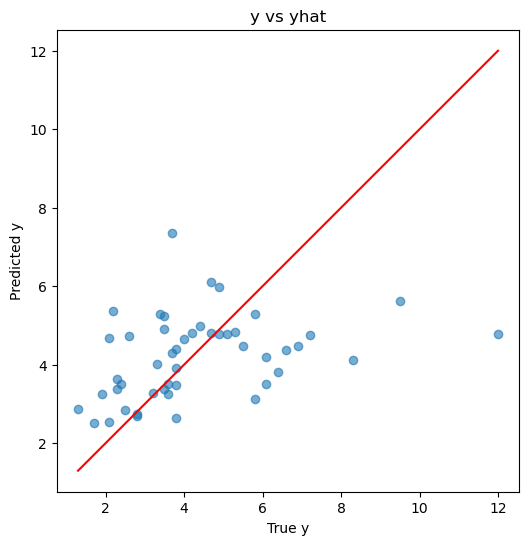

In [6]:
# Best Imputation 3.1 + Best Model 3.2

# 1. SEPARATE LABELED AND UNLABELED DATA
labeled_data = train[train['SurvivalTime'].notna()].copy()
unlabeled_data = train[train['SurvivalTime'].isna()].copy()

feature_cols = [col for col in train.columns 
               if col not in ['SurvivalTime', 'Censored', 'id']]

X_labeled = labeled_data[feature_cols]
y_labeled = labeled_data['SurvivalTime']
c_labeled = labeled_data['Censored']

X_unlabeled = unlabeled_data[feature_cols]

# Test data for Kaggle
X_test_kaggle = test[feature_cols]

# 2. SPLIT LABELED DATA INTO TRAIN/TEST
X_train_labeled, X_test_labeled, y_train_labeled, y_test_labeled, c_train_labeled, c_test_labeled = train_test_split(
    X_labeled, y_labeled, c_labeled, test_size=0.2, random_state=42, stratify=c_labeled
)

print(f"Labeled train: {len(X_train_labeled)}, Labeled test: {len(X_test_labeled)}")
print(f"Unlabeled data: {len(X_unlabeled)}")

# 3. APPLY KNN IMPUTATION TO ALL DATA (labeled_train + unlabeled)
X_train_all = pd.concat([X_train_labeled, X_unlabeled], axis=0)

knn_imputer = KNNImputer(n_neighbors=5)
X_train_all_imputed = knn_imputer.fit_transform(X_train_all)  # Fit on labeled+unlabeled

# Transform test data using the SAME imputer
X_test_labeled_imputed = knn_imputer.transform(X_test_labeled)
X_test_kaggle_imputed = knn_imputer.transform(X_test_kaggle)

# Split back into labeled train and unlabeled
n_labeled_train = len(X_train_labeled)
X_train_labeled_imputed = X_train_all_imputed[:n_labeled_train]
X_unlabeled_imputed = X_train_all_imputed[n_labeled_train:]

# Convert to DataFrames
X_train_df = pd.DataFrame(X_train_labeled_imputed, columns=feature_cols, index=X_train_labeled.index)
X_test_df = pd.DataFrame(X_test_labeled_imputed, columns=feature_cols, index=X_test_labeled.index)

# 4. PREPARE Y FOR AFT FORMAT (TRAIN)
y_train_lower = y_train_labeled.values.copy()
y_train_upper = y_train_labeled.values.copy()
censored_train_mask = (c_train_labeled == 1).values
y_train_upper[censored_train_mask] = np.inf

# Prepare y for AFT format (TEST)
y_test_lower = y_test_labeled.values.copy()
y_test_upper = y_test_labeled.values.copy()
censored_test_mask = (c_test_labeled == 1).values
y_test_upper[censored_test_mask] = np.inf

# 5. TRAIN CATBOOST AFT (SEMI-SUPERVISED)
# Prepare AFT format (inf -> -1)
y_train_upper_aft = y_train_upper.copy()
y_train_upper_aft[y_train_upper_aft == np.inf] = -1

train_pool = Pool(
    data=X_train_df,
    label=np.column_stack([y_train_lower, y_train_upper_aft])
)

# Prepare test pool for evaluation
y_test_upper_aft = y_test_upper.copy()
y_test_upper_aft[y_test_upper_aft == np.inf] = -1

test_pool = Pool(
    data=X_test_df,
    label=np.column_stack([y_test_lower, y_test_upper_aft])
)

# Train CatBoost AFT
cat_aft = CatBoostRegressor(
    loss_function='SurvivalAft:dist=Normal',
    eval_metric='SurvivalAft',
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=100,
    random_seed=42
)

cat_aft.fit(train_pool, eval_set=test_pool)

# 6. EVALUATE
y_pred_train = cat_aft.predict(train_pool, prediction_type='Exponent')
train_error = error_metric(y_train_labeled, y_pred_train, c_train_labeled)
print(f"Training error: {train_error:.4f}")

y_pred_test = cat_aft.predict(test_pool, prediction_type='Exponent')
test_error = error_metric(y_test_labeled, y_pred_test, c_test_labeled)
print(f"Test error: {test_error:.4f}")

# 7. PLOT
plot_y_yhat(y_test_labeled, y_pred_test)
plt.show()
